In [34]:
! pip install scikit-image

In [35]:
import numpy as np
import skimage
import matplotlib.pyplot as plt
from skimage import data
from math import pi, cos, sin

# Реализация рекурсивного FFT
def recursive_fft(x):
    n = len(x)
    if n == 1:
        return x
    even = recursive_fft(x[::2]) #разбиваем на четное и нечетное
    odd = recursive_fft(x[1::2])
    w = [np.exp(-2j*pi*k/n)*odd[k] for k in range(n//2)] #задаем степени w
    return [even[k] + w[k] for k in range(n//2)] + [even[k] - w[k] for k in range(n//2)]

# Двумерное
def my_fft2(image):
    n, m = image.shape
    size_n = 2**int(np.ceil(np.log2(n))) # Приведение размера к степени двойки
    size_m = 2**int(np.ceil(np.log2(m)))
    padded = np.zeros((size_n, size_m), dtype=complex) #расширяем изображение до полученного размера (потом обрежем)
    padded[:n,:m] = image
    
    # FFT по строкам
    temp = np.array([recursive_fft(row) for row in padded])
    
    # FFT по столбцам
    return np.array([recursive_fft(col) for col in temp.T]).T

# Сдвиг частот
def fftshift(fft_img):
    n, m = fft_img.shape
    return np.roll(fft_img, (n//2, m//2), axis=(0,1))
# Обратное
def ifft2(fft_img):
    return np.conj(my_fft2(np.conj(fft_img)))/(fft_img.shape[0]*fft_img.shape[1])

In [36]:
import scipy.io
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

sample_rate, data = wavfile.read('great gig in the sky.wav')
sample_rate2, data2 = wavfile.read('let it happen.wav')

if len(data.shape) > 1:
    data = data.mean(axis=1)

print("Sample rate:", sample_rate)
print("Length:", len(data))

if len(data2.shape) > 1:
    data2 = data2.mean(axis=1)

print("Sample rate:", sample_rate2)
print("Length:", len(data2))

Sample rate: 44100
Length: 12528000
Sample rate: 44100
Length: 20696303


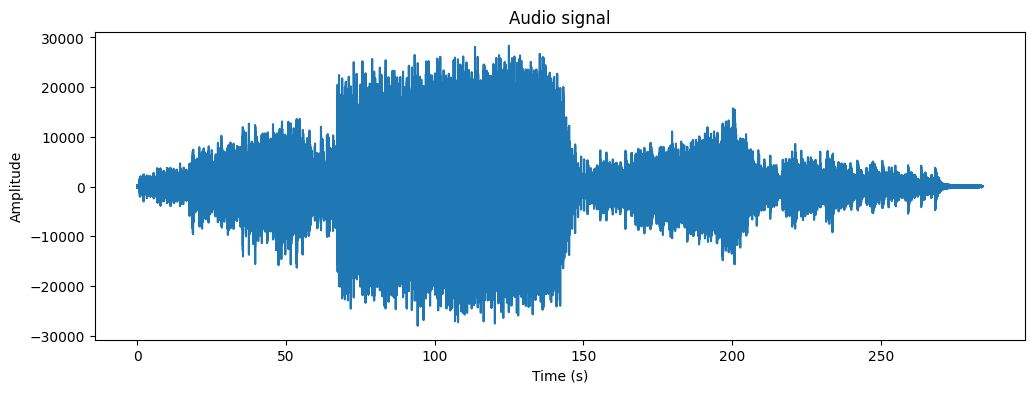

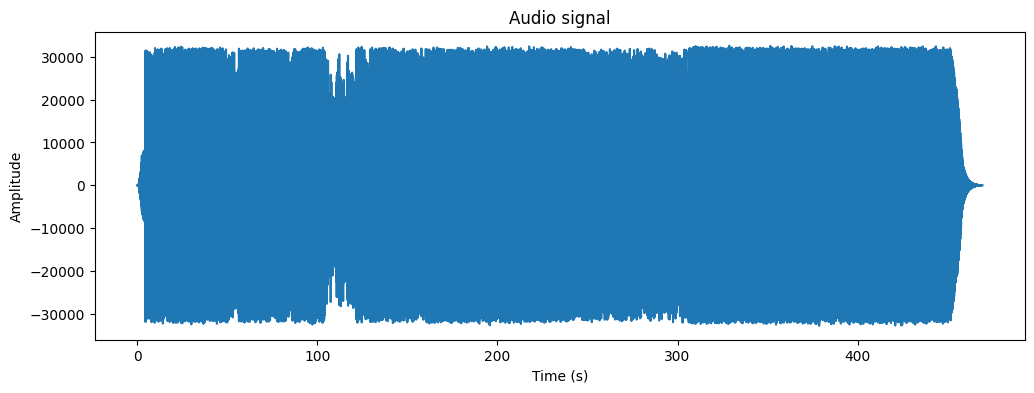

In [37]:
time = np.arange(len(data)) / sample_rate

plt.figure(figsize=(12,4))
plt.plot(time, data)
plt.title("Audio signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

time2 = np.arange(len(data2)) / sample_rate2

plt.figure(figsize=(12,4))
plt.plot(time2, data2)
plt.title("Audio signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

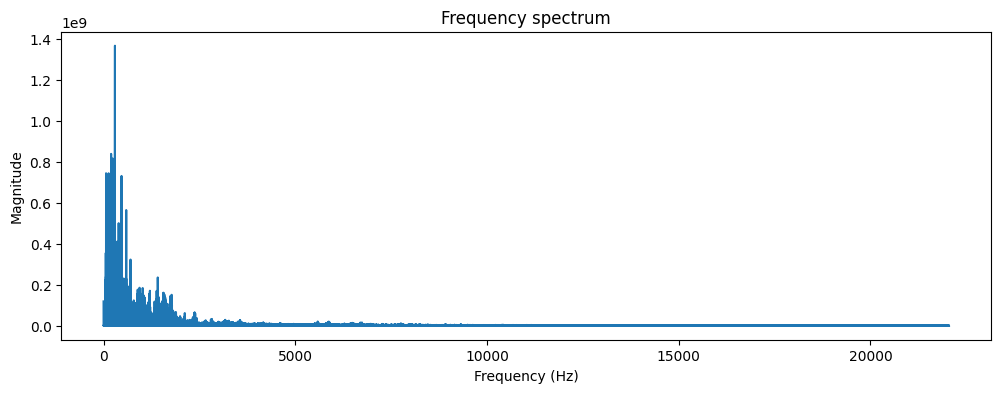

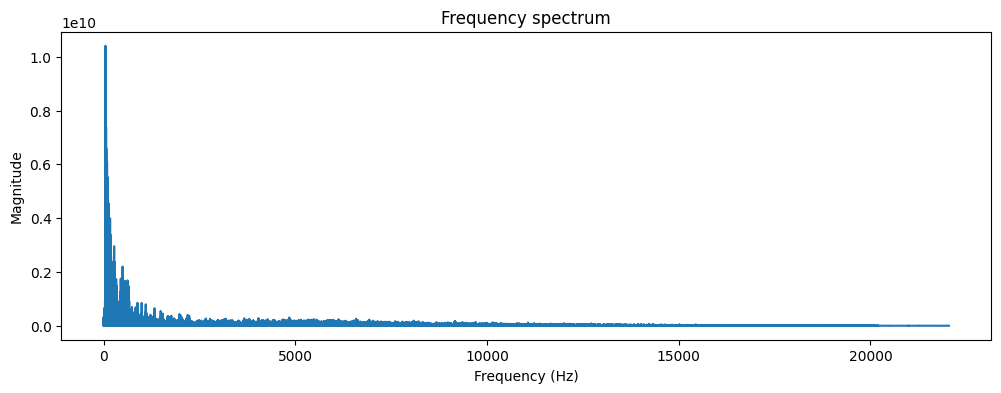

In [38]:
from scipy.fft import fft, ifft, fftfreq

fft_data = fft(data)
freqs = fftfreq(len(data), 1/sample_rate)

plt.figure(figsize=(12,4))
plt.plot(freqs[:len(freqs)//2], np.abs(fft_data)[:len(freqs)//2])
plt.title("Frequency spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()



fft_data2 = fft(data2)
freqs2 = fftfreq(len(data2), 1/sample_rate2)

plt.figure(figsize=(12,4))
plt.plot(freqs2[:len(freqs2)//2], np.abs(fft_data2)[:len(freqs2)//2])
plt.title("Frequency spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [39]:
#Удаление высоких частот

cutoff = 3000  

low_pass = fft_data.copy()
low_pass[np.abs(freqs) > cutoff] = 0

filtered_low1 = np.real(ifft(low_pass))

low_pass2 = fft_data2.copy()
low_pass2[np.abs(freqs2) > cutoff] = 0

filtered_low2 = np.real(ifft(low_pass2))

In [40]:
#Удаляет басы

cutoff = 500  # Hz

high_pass = fft_data.copy()
high_pass[np.abs(freqs) < cutoff] = 0

filtered_high1 = np.real(ifft(high_pass))

high_pass2 = fft_data2.copy()
high_pass2[np.abs(freqs2) < cutoff] = 0

filtered_high2 = np.real(ifft(high_pass2))

In [41]:
#Удаляет басы и высокие частоты

low = 500
high = 3000

band_pass = fft_data.copy()
mask = (np.abs(freqs) > low) & (np.abs(freqs) < high)
band_pass[~mask] = 0

filtered_band1 = np.real(ifft(band_pass))

band_pass2 = fft_data2.copy()
mask2 = (np.abs(freqs2) > low) & (np.abs(freqs2) < high)
band_pass2[~mask2] = 0

filtered_band2 = np.real(ifft(band_pass2))

In [42]:
wavfile.write("low_pass.wav", sample_rate, filtered_low1.astype(np.int16))
wavfile.write("high_pass.wav", sample_rate, filtered_high1.astype(np.int16))
wavfile.write("band_pass.wav", sample_rate, filtered_band1.astype(np.int16))

In [43]:
wavfile.write("low_pass2.wav", sample_rate, filtered_low2.astype(np.int16))
wavfile.write("high_pass2.wav", sample_rate, filtered_high2.astype(np.int16))
wavfile.write("band_pass2.wav", sample_rate, filtered_band2.astype(np.int16))